<a href="https://colab.research.google.com/github/nat6s/D2C-Skincare-E-commerce-Ingestion-and-Analytics-Pipeline/blob/main/AAPL_stock_prices_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

 In this project I will demonstrate how the pandemic hit Apple and how their stock prices changed during those 5 years since 2020.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


First, one of the reliable sources for stock prices is Yahoo Finance. Luckily Python has direct cinnection to it, a library called yfinance from where it's possible to import the data we need.

In [ ]:
df = yf.download("AAPL", start="2020-01-01", end="2025-12-31", interval="1mo")
df.head()

/tmp/ipython-input-300066977.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-12-31", interval="1mo")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-01,74.678368,79.103430,70.634524,71.476586,2934370400
2020-02-01,65.956116,78.951425,61.856782,73.421299,3019279200
2020-03-01,61.500557,73.523024,51.420165,68.269997,6280072400
2020-04-01,71.056107,71.232661,57.294731,59.616511,3265299200
2020-05-01,76.894424,78.418089,69.133395,69.230134,2805936000


# Data Cleaning

As you can see the data we have right now is quite messy, AAPL header hurts the eye, data frame has no name so an average person might be confused what it is about and columns are a little bit out of order. To create beautiful data visualisation it's needed to clean this data frame first.

In [ ]:
# this block removes price and aapl headers to give data frame a moe polished look
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.index.name = None

# while trying to clean the data python started treating it as time frame and gave as an unnesscassary column 00-00-00, this block removes it
df = df.reset_index()
if 'index' in df.columns:
    df = df.rename(columns={'index': 'Date'})
df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')


# it would be more logical to have first the date then the opening price, not closeing one, on the contrary close and adj close should be the last columns
logical_order = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df = df[[col for col in logical_order if col in df.columns]]

# so that the rows will start from 1
df.index = range(1, len(df) + 1)

# we round the numbers so it won't hurt the eye and so the data frame looks cleaner
df = df.dropna().round(2)

# giving data frame a name to avoid confusion
styled_df = df.style.set_caption("AAPL stock prices in USD").set_table_styles([{
    'selector': 'caption',
    'props': [
        ('text-align', 'left'),
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('color', 'white'),
        ('padding-bottom', '10px')
    ]
}])


styled_df

,Date,Open,High,Low,Close,Volume
1,2020-01-01,71.480000,79.100000,70.630000,74.680000,2934370400
2,2020-02-01,73.420000,78.950000,61.860000,65.960000,3019279200
3,2020-03-01,68.270000,73.520000,51.420000,61.500000,6280072400
4,2020-04-01,59.620000,71.230000,57.290000,71.060000,3265299200
5,2020-05-01,69.230000,78.420000,69.130000,76.890000,2805936000
6,2020-06-01,77.060000,90.300000,76.930000,88.470000,3243375600
7,2020-07-01,88.540000,103.230000,86.470000,103.080000,3020283200
8,2020-08-01,104.960000,127.070000,104.660000,125.170000,4070061100
9,2020-09-01,129.010000,134.090000,100.190000,112.540000,3885245100
10,2020-10-01,114.320000,121.850000,104.680000,105.790000,2894666500


# Data visualisation

Now that we have clean polished data, we can easily visualise it whatever way we please. First since our data frame contains data from each month, let's visualise how AAPL stock price grew each year from january to december and compare each years' growth.

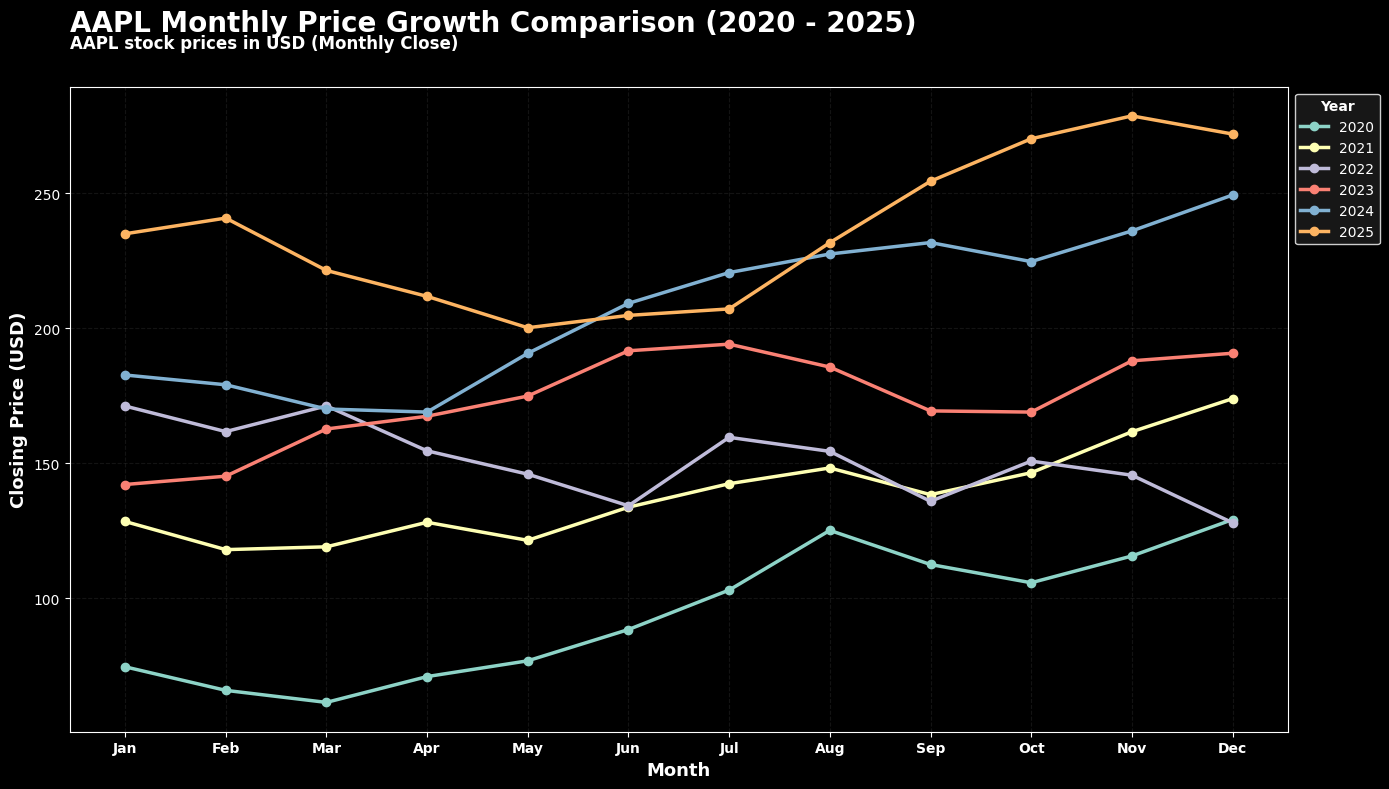

In [ ]:


# in original yahoo finance data, date is an index, move date from index to column so it can be found and not raise keyerror
if 'Date' not in df.columns:
    df = df.reset_index().rename(columns={'index': 'Date', 'Date': 'Date'})

# flatten multiIndex headers if they exist
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# preparing the data
df['Date_dt'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date_dt'].dt.month
df['Year'] = df['Date_dt'].dt.year

# we will use values "close" column as it is considered the "primary" one of the time period
pivot_close = df.pivot_table(index='Month', columns='Year', values='Close', aggfunc='mean')

# visualising
plt.style.use('dark_background')
plt.figure(figsize=(14, 8))


month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# plotting each year from 2020 to 2025
for year in pivot_close.columns:
    plt.plot(pivot_close.index, pivot_close[year],
             marker='o', markersize=6, linewidth=2.5, label=str(year))

# 4. STYLING (Bold White & Top-Left Aligned)
plt.title('AAPL Monthly Price Growth Comparison (2020 - 2025)',
          fontsize=20, fontweight='bold', pad=40, loc='left', color='white')

plt.xlabel('Month', fontsize=13, fontweight='bold', color='white')
plt.ylabel('Closing Price (USD)', fontsize=13, fontweight='bold', color='white')

# this block sets the x asix to months
plt.xticks(range(1, 13), month_names, color='white', fontweight='bold')
plt.yticks(color='white')

# legend Styling (Placed to the right so it doesn't block the lines)
legend = plt.legend(title="Year", frameon=True, facecolor='#1e1e1e',
                    edgecolor='white', loc='upper left', bbox_to_anchor=(1, 1))
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white', fontweight='bold')

# background styling
plt.grid(True, linestyle='--', alpha=0.15, color='gray')
plt.gca().set_facecolor('none')

# the header(what the graph is about)
plt.text(0, 1.06, "AAPL stock prices in USD (Monthly Close)", transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# What we got from this data

As we can see that 2020 was the lowest year for Apple out of all. There is a specific pattern I would like to mention here. As we know covid first broke out at the end of 2019 and as we see from jan 2020 to march 2020 AAPL stock slowly goes down, until the actual pandemic hits, but from march 2020 to aug 2020 the stock price rises. Why is that? One of the main known reasons is the fact that during the pandemic many people started aquiring gadgets in order to be able to work and study from home comfortably and efficently. Of course Apple benefited from this thus the shares price went up greately.

# Mean vs Median

Here I visualised the mean vs median of each year. We can see how the numbers changed from 2020-2025

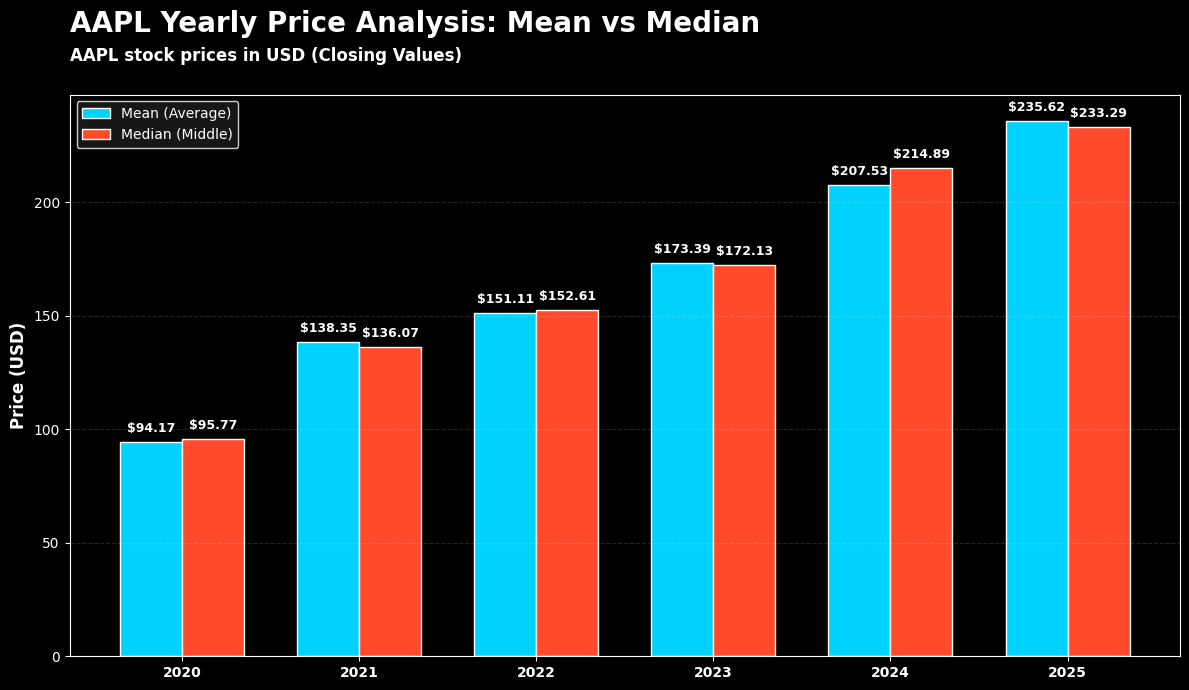

In [ ]:


# yahoo finance data, date is an index not a column, in order to avoid getting keyerrors we have to run this block
if 'Date' not in df.columns:
    df = df.reset_index().rename(columns={'index': 'Date', 'Date': 'Date'})

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


df['Date_dt'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date_dt'].dt.year

# calculates  the mean and median
yearly_stats = df.groupby('Year')['Close'].agg(['mean', 'median']).round(2)

# visualising with a dark background to avoid visibility issues
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))

years = yearly_stats.index.astype(str)
x = np.arange(len(years))  # position of groups on x-axis
width = 0.35              # width of the bars

# create grouped bars
rects1 = ax.bar(x - width/2, yearly_stats['mean'], width,
                label='Mean (Average)', color='#00d2ff', edgecolor='white')
rects2 = ax.bar(x + width/2, yearly_stats['median'], width,
                label='Median (Middle)', color='#ff4b2b', edgecolor='white')


ax.set_title('AAPL Yearly Price Analysis: Mean vs Median',
             fontsize=20, fontweight='bold', pad=45, loc='left', color='white')

ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold', color='white')
ax.set_xticks(x)
ax.set_xticklabels(years, color='white', fontweight='bold')
ax.tick_params(axis='y', colors='white')


legend = ax.legend(facecolor='#1e1e1e', edgecolor='white')
plt.setp(legend.get_texts(), color='white')

# add price labels on top of each bar
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

add_labels(rects1)
add_labels(rects2)


ax.text(0, 1.06, "AAPL stock prices in USD (Closing Values)", transform=ax.transAxes,
         fontsize=12, fontweight='bold', color='white')

plt.grid(axis='y', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.show()

It is clear that the difference between mean and median is thrivial. In a way this shows that each year Apple's growth holds stability.

# Price VS Volume

Although talking about prices gives us enough insites about the company one of the main factors is HOW MANY shares were actually sold. This is a crucial data and it will give us a new percpective to think about.

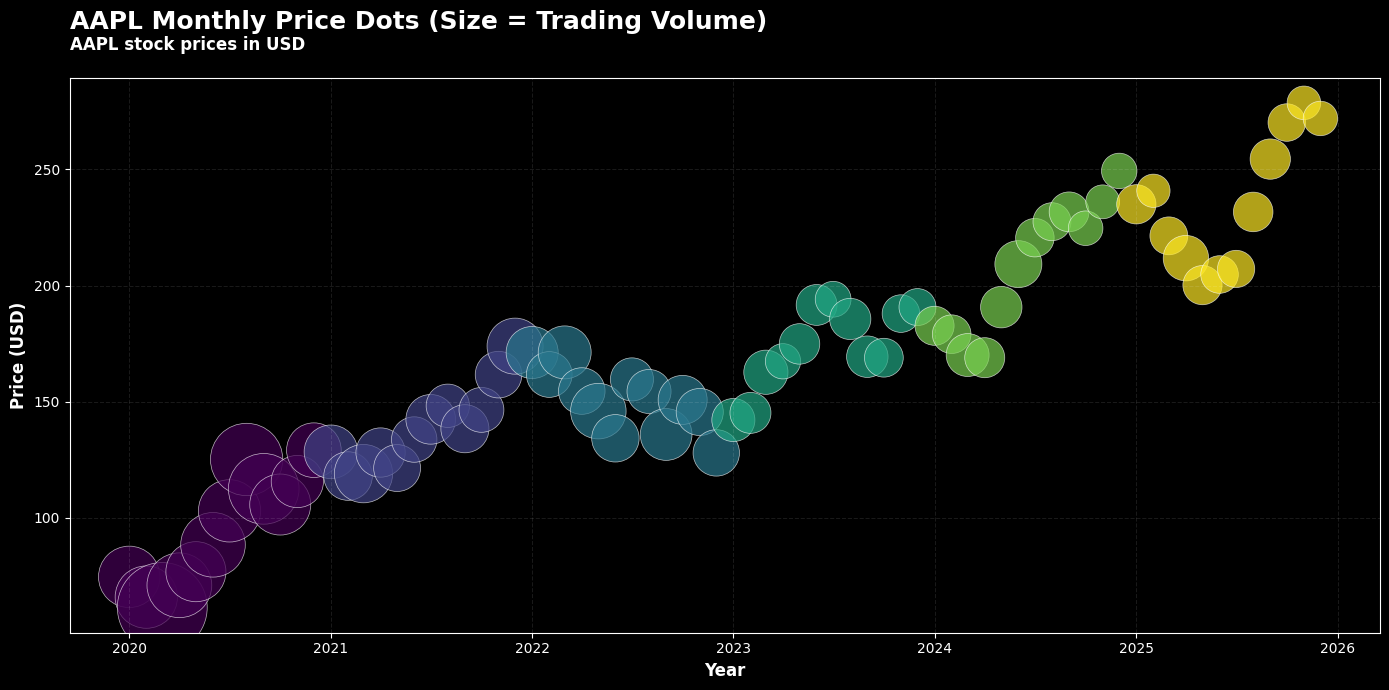

In [ ]:
if 'Date' not in df.columns:
    df = df.reset_index().rename(columns={'index': 'Date'})


df['Date_dt'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date_dt'].dt.year

# dot(bubble) style
plt.style.use('dark_background')
plt.figure(figsize=(14, 7))

# determine the size of the bubble based on the volume
dot_sizes = df['Volume'] / 1_500_000

# create the scatter dot/bubble plot
scatter = plt.scatter(df['Date_dt'], df['Close'],
                      s=dot_sizes,
                      c=df['Year'],
                      cmap='viridis',
                      alpha=0.7,
                      edgecolors='white',
                      linewidth=0.5)

# header to show what the plot is about
plt.title('AAPL Monthly Price Dots (Size = Trading Volume)',
          fontsize=18, fontweight='bold', pad=35, loc='left', color='white')

plt.ylabel('Price (USD)', fontsize=12, fontweight='bold', color='white')
plt.xlabel('Year', fontsize=12, fontweight='bold', color='white')

# x and y axis styling
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(True, linestyle='--', alpha=0.1)


plt.text(0, 1.05, "AAPL stock prices in USD", transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

Here we see not so shocking picture. As hed prices hit rocket low during 2020-2021 period and because during those times investing in shares was quite popular , Apple sold the most shares in the last five yeras. Gradually the prices incresed and volume slowly decreased.

# 2020 VS 2025 peak comparision

It is common to consider the "official" price data the price of the share at the end of the day. Since our starting data frame was on monthly bases we have the average of all month. But to draw an interesting comparision between 2020 and 2025 we should compare the highest prices and see what the highest month of 2020 will look like next to the one in 2025.

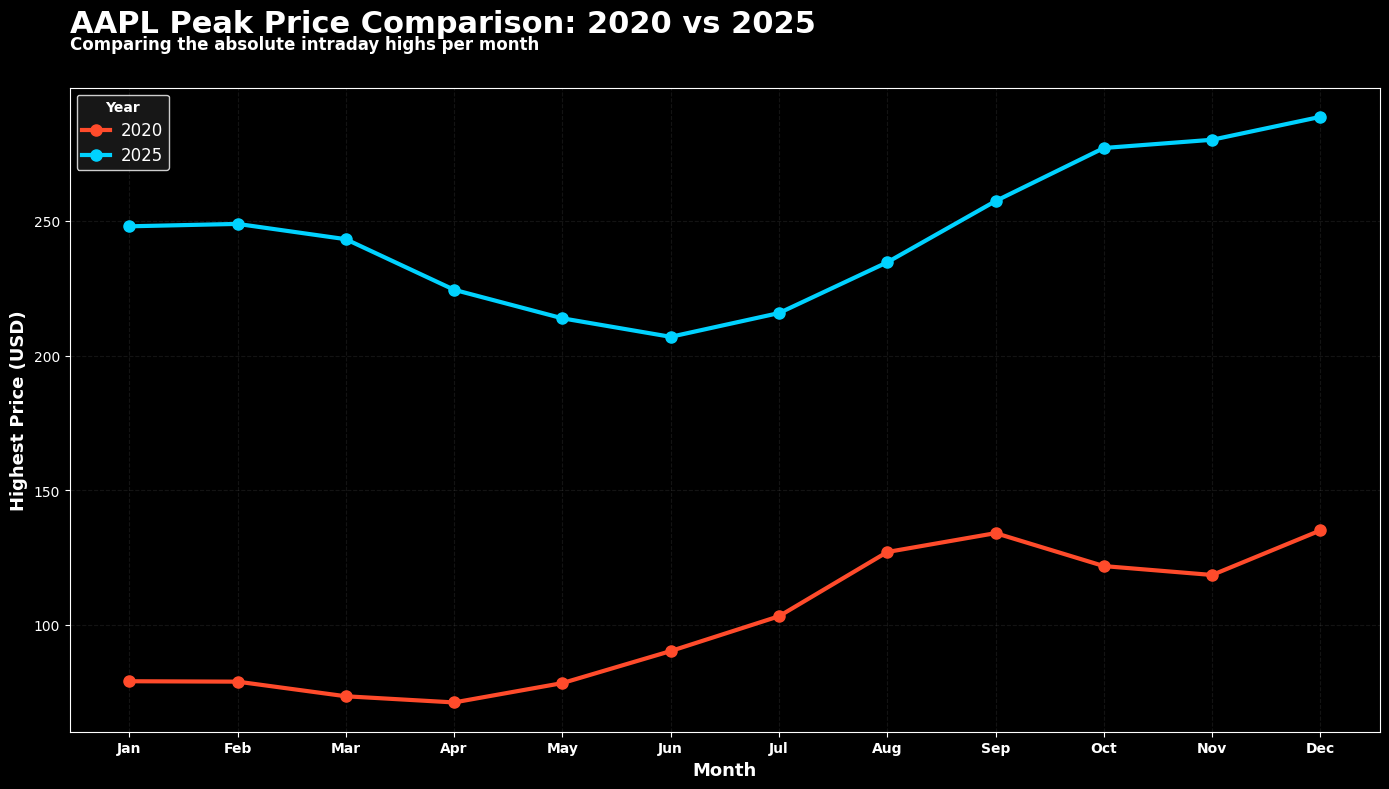

In [ ]:

# flatten MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# yahoo finance data, date is an index not a column, in order to avoid getting keyerrors we have to run this block
if 'Date' not in df.columns:
    df = df.reset_index().rename(columns={'index': 'Date'})

df['Date_dt'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date_dt'].dt.year
df['Month'] = df['Date_dt'].dt.month

# take only 2020 and 2025
df_filtered = df[df['Year'].isin([2020, 2025])]


# instead of values in close column we take the ones in high
pivot_highs = df_filtered.pivot_table(index='Month', columns='Year', values='High', aggfunc='max')

# visualising
plt.style.use('dark_background')
plt.figure(figsize=(14, 8))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = {2020: '#ff4b2b', 2025: '#00d2ff'} # Contrasting colors for clear comparison

for year in pivot_highs.columns:
    plt.plot(pivot_highs.index, pivot_highs[year],
             marker='o', markersize=8, linewidth=3,
             label=str(year), color=colors.get(year))

# header
plt.title('AAPL Peak Price Comparison: 2020 vs 2025',
          fontsize=22, fontweight='bold', pad=40, loc='left', color='white')


plt.xlabel('Month', fontsize=13, fontweight='bold', color='white')
plt.ylabel('Highest Price (USD)', fontsize=13, fontweight='bold', color='white')

plt.xticks(range(1, 13), month_names, color='white', fontweight='bold')
plt.yticks(color='white')


legend = plt.legend(title="Year", frameon=True, facecolor='#1e1e1e', edgecolor='white', loc='upper left')
plt.setp(legend.get_texts(), color='white', fontsize=12)
plt.setp(legend.get_title(), color='white', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.15, color='gray')
plt.gca().set_facecolor('none')


plt.text(0, 1.06, "Comparing the absolute intraday highs per month", transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

A happy picture for Apple. The month with the highest price in 2020 aka september isn't even close to the lowest one in 2025(june), the letter's price is nearly 1.5 more.

# Conclusion

Based on everything shown above I have drawn the following conclusion.
even though the pandemic crisis hit Apple, just like any other company, in the span of five years they have grown and upgradet a lot, once again securing their place as one of the tech tychoons of our generation. The growth is stable, showing that the company values stability and constant improvements, with the amazing launchs and innovation they are countinueing to grow the value and demand of their company and it's products.